In [1]:
import os
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, DataCollatorForTokenClassification,
    DataCollatorWithFlattening
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from sklearn.metrics import (accuracy_score,classification_report, 
confusion_matrix, balanced_accuracy_score, f1_score)
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Modelo de GPU: {torch.cuda.get_device_name(0)}")

GPU disponible: True
Modelo de GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
#Extracción de rutas para la lectura y derivación de archivos
PROJECT_ROOT = Path(os.getcwd()).parent

# Ruta completa a carpetas
MODELOS_PATH = PROJECT_ROOT / 'modelos'
DATOS_PATH = PROJECT_ROOT / 'data' / 'limpieza_final' / 'etiquetado_humano_unificado.csv'
print(str(MODELOS_PATH))
print(str(DATOS_PATH))
corpus = pd.read_csv(DATOS_PATH, usecols = ['comentario', 'etiquetado_humano','categoria'],encoding = 'utf-8-sig')
print(corpus.head())

C:\Users\inqui\OneDrive\Desktop\Clases\26-2\LLM_PROJECT_1\modelos
C:\Users\inqui\OneDrive\Desktop\Clases\26-2\LLM_PROJECT_1\data\limpieza_final\etiquetado_humano_unificado.csv
                                          comentario  etiquetado_humano  \
0  cuál es el más cercado para rayar el nombre de...                3.0   
1  esos baños deberian estar en el metro no saben...                2.0   
2                           no pues bueno me da risa                3.0   
3                                los van a abandonar                2.0   
4                           nada los tiene contentos                4.0   

         categoria  
0  infraestructura  
1  infraestructura  
2  infraestructura  
3  infraestructura  
4  infraestructura  


In [3]:
#Nos quedamos unicamente con los datos que tienen etiqueta, pues estamos
#realizando un aprendizaje supervisado
muestra = corpus[np.isnan(corpus['etiquetado_humano']) == False]

#Se renombran la columnas columnas 'etiquetado_humano' y 'comentario' 
#como 'labels' y 'text' como requerimiento para hacer el fine tuning
muestra.rename(columns = {'etiquetado_humano':'labels','comentario':'text'}, inplace = True)
muestra['labels'] = [int(x-1) for x in muestra['labels']]

#Para evitar problemas de correlacion (inducidos por las categorias),
#hacemos un reordenamiento aleatorio de nuestros datos
muestra = muestra.sample(n = len(muestra['text']))
muestra_ds = Dataset.from_pandas(muestra)


print(muestra.head())

semilla = 61298

                                                   text  labels  \
1963  fijate que no estaría mal yo trabajo de didi p...       2   
55                                             jajajajj       2   
873   morena preocupándose por otra gente menos por ...       0   
25    pero que tal los baños de los metrobuses ya lo...       0   
27                                                    y       2   

            categoria  
1963          turismo  
55    infraestructura  
873         seguridad  
25    infraestructura  
27    infraestructura  


In [4]:
# Cargamos el tokenizador del modelo que decidimos usar
modelo = 'nlptown/bert-base-multilingual-uncased-sentiment'
tokenizer = AutoTokenizer.from_pretrained(modelo)

#Funcion simple para pasar de lenguaje natural a 'lenguaje de LLM'
def tokenizar(dato):
    return tokenizer(dato['text'], truncation = True, max_length = 580, padding = False)

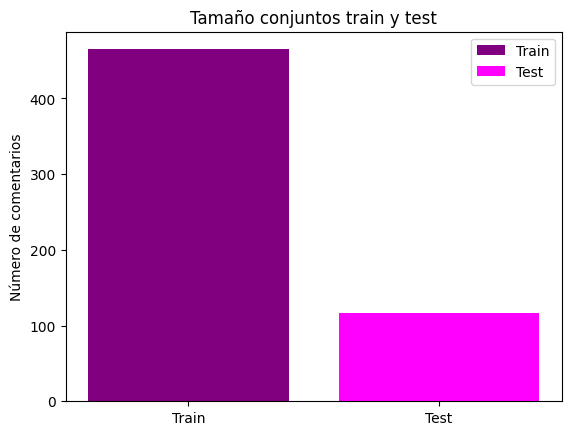

In [5]:
tam_train = len(muestra) * .8
tam_test = len(muestra) * .2

plt.bar(['Train','Test'],[tam_train,tam_test], label = ['Train','Test'],color = ['purple','magenta'])
plt.title('Tamaño conjuntos train y test')
plt.ylabel('Número de comentarios')
plt.legend()
plt.show()

In [18]:
#Primero definimos el clasificador al que le haremos el finefuning y los parametros necesarios para el mismo,
#entre ellos, las etiquetas de "ida y de vuelta" de la clasificacion
clasificador = AutoModelForSequenceClassification.from_pretrained(
    modelo,
    num_labels = 5,
    id2label= {0:'Negativo',1:'Parcialmente Negativo', 2:'Neutral',3:'Parcialmente Positivo', 4:'Postivo'},
    label2id={'Negativo':0,'Parcialmente Negativo':1, 'Neutral': 2, 'Parcialmente Positivo': 3, 'Positivo':4}
)

#Ahora, configuramos LORA
lora_config = LoraConfig(
    task_type = TaskType.SEQ_CLS,   # clasificación de secuencias
    r=16,              # rango: dimensión de las matrices B y A
                      # valores típicos: 4, 8, 16, 32, 64
                      # mayor r = más capacidad, más parámetros
    lora_alpha=32,    # escala: controla cuánto pesa ΔW vs W original
                      # regla general: lora_alpha = 2 * r
                      # el peso efectivo es (lora_alpha / r) * BA
    lora_dropout=0.1, # dropout aplicado a las capas LoRA (regularización)
    bias='none',      # no adaptar los sesgos (más eficiente)
    target_modules=[  # ¿en qué capas de BERT aplicar LoRA?
        'query',      # proyección Q en self-attention
        'value',      # proyección V en self-attention
        # 'key', 'dense' — se pueden agregar para más capacidad
    ],
)

#El fine tuning lo hacemos con lora a traves de peft:
#Parameter-Efficient Fine-Tuning (PEFT) methods enable efficient adaptation of large pretrained models 
#to various downstream applications by only fine-tuning a small number of (extra) model parameters 
#instead of all the model's parameters. This significantly decreases the computational and storage costs. 
#Recent state-of-the-art PEFT techniques achieve performance comparable to fully fine-tuned models.
clasificador_peft = get_peft_model(clasificador, lora_config)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [20]:
#Definimos las metricas con las que evaluaremos el modelo
#Ademas de reemplazar el trainer convencional de Transformers por un trainer
#con ponderaciones
def metricas(eval_pred):
    logits, labels = eval_pred
    predicciones = np.argmax(logits, axis=-1)

    f1_macro = f1_score(labels, predicciones, average='macro', zero_division=0)
    f1_weighted = f1_score(labels, predicciones, average='weighted', zero_division=0)
    accuracy = (predicciones == labels).mean()
    bal_accuracy = balanced_accuracy_score(labels,predicciones)
    return {'f1_macro': f1_macro, 'f1_weighted': f1_weighted,'accuracy': accuracy,'balanced accuracy':bal_accuracy}



# Trainer personalizado
class WeightedLossTrainer(Trainer):
    """Trainer que usa class weights para manejar clases desbalanceadas"""
    
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    # num_items_in_batch=num_items_in_batch
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch = 0):
        """
        Sobrescribe el método compute_loss para usar class weights
        """
        labels = inputs.get("labels")
        
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get('logits')
        
        # Calcular loss con pesos si están disponibles
        if self.class_weights is not None:
            device = labels.device
            weights = self.class_weights.to(device)
            
            loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
            loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        else:
            # Fallback a loss estándar
            loss = outputs.loss
            
        return (loss, outputs) if return_outputs else loss



# Función para calcular pesos desde un dataset
def calcular_class_weights(dataset, num_labels=5):
    """
    Calcula los pesos de clase a partir de un dataset de Hugging Face
    
    Args:
        dataset: Dataset de Hugging Face con columna 'label'
        num_labels: número de clases
    
    Returns:
        torch.Tensor con los pesos para cada clase
    """
    # Extraer todas las etiquetas del dataset
    #print(dataset)
    labels = [example['labels'] for example in dataset]
    
    # Calcular pesos usando sklearn
    class_weights = compute_class_weight(
        class_weight='balanced',  # inversamente proporcional a frecuencia
        classes=np.unique(labels),
        y=labels
    )
    
    # Convertir a tensor de torch
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

    '''
    # Mostrar información (opcional)
    print(f"\n  📊 Distribución en entrenamiento:")
    for i in range(num_labels):
        count = labels.count(i)
        print(f"     Clase {i}: {count:5d} ejemplos, Peso = {weights_tensor[i]:.4f}")
    '''
    return weights_tensor

In [23]:
#Una especie de preprocesado (o cargado) del tokenizador para 
#utilizarlo despues en el tuneo
colador = DataCollatorWithPadding(tokenizer = tokenizer)
#colador = DataCollatorWithFlattening(tokenizer = tokenizer)
#colador = DataCollatorForTokenClassification(tokenizer = tokenizer)


training_args = TrainingArguments(
    output_dir = MODELOS_PATH,

    # Épocas y batch
    num_train_epochs=10,              # 3 épocas suele ser suficiente para LoRA
    per_device_train_batch_size=8,  # ejemplos por paso en GPU
    per_device_eval_batch_size=16,

    # Learning rate
    learning_rate=1e-4,              # más alto que full FT (1e-5 a 5e-5)
                                     #
                                     #LoRA puede tolerar LR más altos
    lr_scheduler_type='cosine',      # decae suavemente hasta 0
    warmup_steps=0.1,                # 10% de pasos para calentamiento

    # Evaluación y guardado
    eval_strategy='epoch',           # evaluar al final de cada época
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='balanced accuracy',
    greater_is_better=True,

    # Eficiencia
    fp16=torch.cuda.is_available(),  # precisión mixta si hay GPU
    dataloader_num_workers=2,

    # Logging
    logging_steps=50,
    report_to='none',                # desactivar wandb/tensorboard
)

# Mover modelo al dispositivo
if device == 'cuda':
    clasificador_peft = clasificador_peft.to('cuda')


def entrenar_cv(folds_cv, modelo, num_epochs=3):
    """Entrena un modelo para cada fold y devuelve métricas"""
    
    resultados = []
    
    for fold_idx, fold in enumerate(folds_cv):
        print(f"\n{'='*50}")
        print(f"Entrenando Fold {fold_idx + 1}/{len(folds_cv)}")
        print(f"{'='*50}")
        
        #Calcular class weights desde el dataset de entrenamiento de este fold
        class_weights = calcular_class_weights(fold['train'], num_labels=5)

        clasificador = AutoModelForSequenceClassification.from_pretrained(
            modelo,
            num_labels=5,
            id2label={0:'Negativo',1:'Parcialmente Negativo', 2:'Neutral',3:'Parcialmente Positivo', 4:'Positivo'},
            label2id={'Negativo':0,'Parcialmente Negativo':1, 'Neutral': 2, 'Parcialmente Positivo': 3, 'Positivo':4}
        )

        # Configuramos LORA
        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=32,
            lora_alpha=64,
            lora_dropout=0.2,
            bias='lora_only',
            target_modules=['query', 'value', 'key', 'dense'],
        )
        
        modelo_lora = get_peft_model(clasificador, lora_config)
        if device == 'cuda':
            modelo_lora = modelo_lora.to('cuda')
        
        #Usar WeightedLossTrainer en lugar de Trainer estándar
        trainer = WeightedLossTrainer(
            model=modelo_lora,
            args=training_args,
            train_dataset=fold['train'],
            eval_dataset=fold['validation'],
            data_collator=colador,
            compute_metrics=metricas,
            class_weights=class_weights,  # ← ¡Aquí pasamos los pesos!
        )
        
        # Entrenar
        trainer.train()
        
        # Evaluar
        eval_results = trainer.evaluate()
        eval_results['fold'] = fold_idx + 1
        resultados.append(eval_results)
        
        #Limpiar memoria para el siguiente fold
        del modelo_lora
        del clasificador
        torch.cuda.empty_cache()
    
    # Mostrar resultados promedio
    print("\n" + "="*50)
    print("RESULTADOS FINALES DE CROSS VALIDATION")
    print("="*50)
    
    print(resultados)
    accuracies = [r['eval_accuracy'] for r in resultados]
    accuracies_bal = [r['eval_balanced accuracy'] for r in resultados]
    f1_scores = [r['eval_f1_weighted'] for r in resultados]
    
    print(f"Accuracy promedio: {np.mean(accuracies):.4f} (±{np.std(accuracies):.4f})")
    print(f"Accuracy balanceada promedio: {np.mean(accuracies_bal):.4f} (±{np.std(accuracies_bal):.4f})")
    print(f"F1-Score promedio: {np.mean(f1_scores):.4f} (±{np.std(f1_scores):.4f})")
    
    return resultados

Realizamos ahora el tuneo usando 5-cross validation, seleccionando el modelo con el balanced accuracy más alto.

In [ ]:
#k-cross validation para fine tuning
def k_cross_folds(dataset, k=5, seed=61298):
    """Usa KFold de scikit-learn para crear los folds"""
    kf = KFold(n_splits = k, shuffle = True, random_state = seed)
    
    # Convertir a lista de índices
    indices = list(range(len(dataset)))
    
    folds = []
    for train_idx, val_idx in kf.split(indices):
        folds.append({
            'train': dataset.select(train_idx),
            'validation': dataset.select(val_idx)
        })
    
    return folds

# K-Fold simple

folds = k_cross_folds(muestra_ds, k=10, seed=semilla)
#print(folds)

folds_tokenizados = []
for j in folds:
    #print(j)
    j = DatasetDict({'train': j['train'], 'validation': j['validation'],
                         'test': j['validation']})    
    folds_tokenizados.append(j.map(tokenizar, batched=True, remove_columns=['text']))

modelo = 'nlptown/bert-base-multilingual-uncased-sentiment'
#Finalmente entrenamos y revisamos metricas con 5-cross validation
inicio = time.time()
resultados_cv = entrenar_cv(folds_tokenizados, modelo, num_epochs=3)
fin = time.time()
tiempo_total = fin - inicio


print(f"\nEntrenamiento completo.")
print(f"Tiempo total: {tiempo_total:.4f}s") 

Map:   0%|          | 0/522 [00:00<?, ? examples/s]

Map:   0%|          | 0/59 [00:00<?, ? examples/s]

Map:   0%|          | 0/59 [00:00<?, ? examples/s]

Map:   0%|          | 0/523 [00:00<?, ? examples/s]

Map:   0%|          | 0/58 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy,Balanced accuracy
1,1.630627,2.006053,0.290160,0.426311,0.465517,0.321583
2,1.443727,2.023436,0.236538,0.337865,0.362069,0.264794
3,1.428502,1.909176,0.393131,0.526551,0.534483,0.394103
4,1.040208,2.111217,0.411472,0.556016,0.568966,0.407637
5,0.894169,2.148995,0.354727,0.486247,0.482759,0.352528
6,0.675988,3.011392,0.319752,0.469845,0.482759,0.333481
7,0.531519,3.132458,0.397448,0.494775,0.517241,0.445245
8,0.430073,3.091776,0.396970,0.493469,0.517241,0.445245
9,0.476353,3.023689,0.406862,0.507498,0.534483,0.455772
10,0.372735,3.019025,0.406862,0.507498,0.534483,0.455772


Training Loss,Validation Loss,Epoch,F1 Macro,F1 Weighted,Accuracy,Balanced accuracy
0.372735,3.024298,10,0.406862,0.507498,0.534483,0.455772



Entrenando Fold 3/10


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy,Balanced accuracy
1,1.594325,1.532239,0.262575,0.416157,0.431034,0.273333
2,1.506111,1.482187,0.274848,0.426437,0.431034,0.303636
3,1.328407,1.482118,0.292079,0.380644,0.379310,0.286667
4,1.081566,1.692156,0.335109,0.452475,0.448276,0.341818
5,0.861002,2.149733,0.388400,0.495948,0.500000,0.407879
6,0.916811,2.046040,0.369202,0.475085,0.465517,0.363333


Echemosle un pequeño ojo a nuestro modelo: